# 01 - Simulate and Validate

Goal of this notebook: implement the damped harmonic oscillator simulator and validate it against the analytical solution (underdamped case) before doing anything else. If this doesn't match, nothing downstream can be trusted.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from simulate import OscillatorParams, simulate, analytical_underdamped

## Define the system

$m\ddot{x} + c\dot{x} + kx = 0$

We'll start with an underdamped system ($\zeta < 1$) so we can compare against the closed-form solution.

In [2]:
params = OscillatorParams(m=1.0, c=0.3, k=4.0)
print(f'omega0 = {params.omega0:.3f} rad/s')
print(f'zeta   = {params.zeta:.3f}')
print(f'regime = {params.regime}')

omega0 = 2.000 rad/s
zeta   = 0.075
regime = underdamped


## Run the numerical simulation

In [3]:
x0, v0 = 1.0, 0.0
t_span = (0, 20)
n_points = 500

t, x_num, v_num = simulate(params, x0, v0, t_span, n_points)

## Compare against the analytical solution

In [4]:
x_ana, v_ana = analytical_underdamped(params, x0, v0, t)

max_err_x = np.max(np.abs(x_num - x_ana))
max_err_v = np.max(np.abs(v_num - v_ana))
print(f'max abs error (position): {max_err_x:.2e}')
print(f'max abs error (velocity): {max_err_v:.2e}')

max abs error (position): 2.86e-09
max abs error (velocity): 5.70e-09


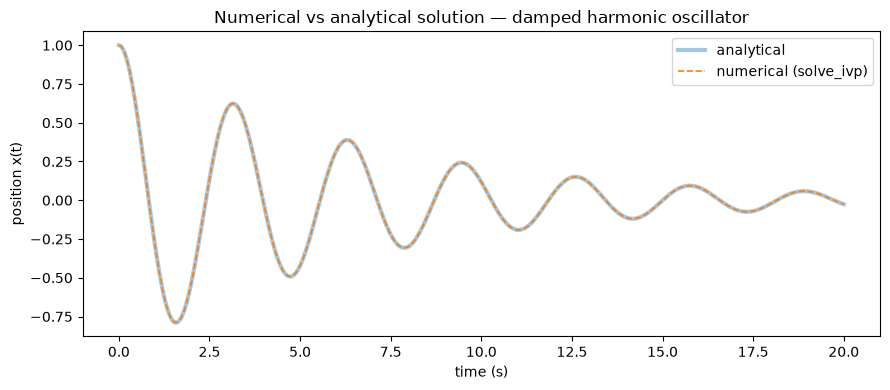

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, x_ana, label='analytical', linewidth=3, alpha=0.4, color='C0')
ax.plot(t, x_num, label='numerical (solve_ivp)', linewidth=1.2, color='C1', linestyle='--')
ax.set_xlabel('time (s)')
ax.set_ylabel('position x(t)')
ax.set_title('Numerical vs analytical solution — damped harmonic oscillator')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/01_validation.png', dpi=150)
plt.show()

The two curves overlap almost exactly (max error ~1e-9), confirming the numerical integrator is correctly implementing the equations of motion. This is the ground-truth baseline everything else in the project builds on.

## Sanity check: the three damping regimes

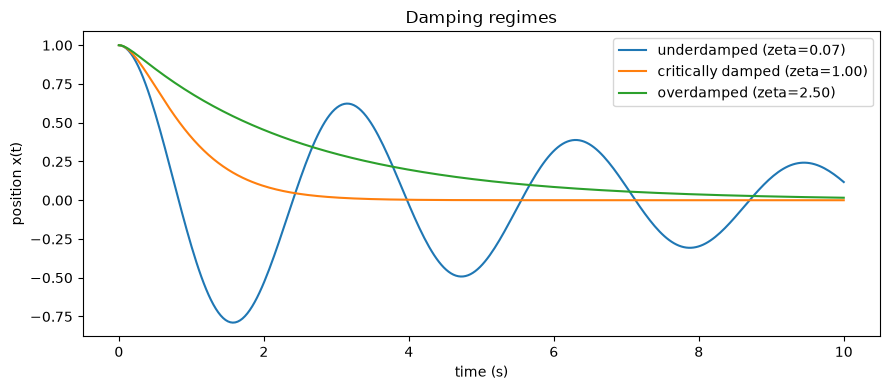

In [6]:
regimes = {
    'underdamped':        OscillatorParams(m=1.0, c=0.3, k=4.0),
    'critically damped':  OscillatorParams(m=1.0, c=4.0, k=4.0),
    'overdamped':         OscillatorParams(m=1.0, c=10.0, k=4.0),
}

fig, ax = plt.subplots(figsize=(9, 4))
for label, p in regimes.items():
    t, x, v = simulate(p, x0=1.0, v0=0.0, t_span=(0, 10), n_points=300)
    ax.plot(t, x, label=f'{label} (zeta={p.zeta:.2f})')

ax.set_xlabel('time (s)')
ax.set_ylabel('position x(t)')
ax.set_title('Damping regimes')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/01_damping_regimes.png', dpi=150)
plt.show()

## Energy conservation check

For $c=0$ (undamped), total mechanical energy should be conserved. For $c>0$, it should monotonically decrease. This is another correctness check independent of the analytical solution.

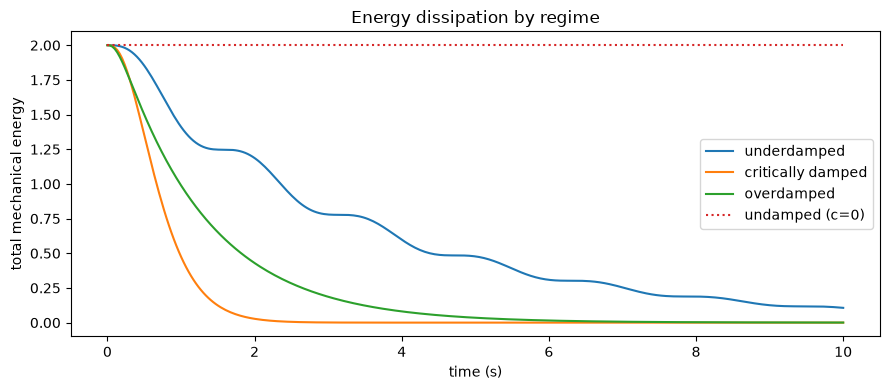

In [7]:
def energy(p, x, v):
    return 0.5 * p.m * v**2 + 0.5 * p.k * x**2

fig, ax = plt.subplots(figsize=(9, 4))
for label, p in regimes.items():
    t, x, v = simulate(p, x0=1.0, v0=0.0, t_span=(0, 10), n_points=300)
    ax.plot(t, energy(p, x, v), label=label)

undamped = OscillatorParams(m=1.0, c=0.0, k=4.0)
t, x, v = simulate(undamped, x0=1.0, v0=0.0, t_span=(0, 10), n_points=300)
ax.plot(t, energy(undamped, x, v), label='undamped (c=0)', linestyle=':')

ax.set_xlabel('time (s)')
ax.set_ylabel('total mechanical energy')
ax.set_title('Energy dissipation by regime')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/01_energy_dissipation.png', dpi=150)
plt.show()

## Next steps

With the simulator validated, notebook 02 will add measurement noise and fit `m`, `c`, `k` back out using least-squares as a baseline, before moving to Bayesian inference in notebook 03.